# Denoising Diffusion Probabilistic Model (DDPM) for MNIST
## Pure NumPy — No PyTorch or TensorFlow

A complete DDPM (Ho et al., 2020) implemented from scratch with NumPy,
Matplotlib, and the Python standard library.

**Contents**

| § | Topic |
|:--|:------|
| 1 | Theory: forward process, reverse process, training objective |
| 2 | Imports, helpers, Adam optimiser |
| 3 | Noise schedule and closed-form forward diffusion |
| 4 | Sinusoidal time embedding |
| 5 | Time-conditioned noise-prediction network $\varepsilon_\theta(x_t,t)$ |
| 6 | Manual backpropagation through the network |
| 7 | MNIST loading (pure Python) |
| 8 | Forward diffusion visualisation |
| 9 | Training |
| 10 | DDPM sampling — full 1000-step reverse chain |
| 11 | DDIM accelerated sampling — 50 deterministic steps |
| 12 | Analysis: denoising quality, chain evolution, noise scatter |

## 1. Theory

### 1.1 Forward process — adding noise

The forward process turns a clean image $x_0$ into noise in $T$ steps:

$$q(x_t \mid x_{t-1})
= \mathcal{N}\!\bigl(x_t;\;\sqrt{1-\beta_t}\,x_{t-1},\;\beta_t\mathbf{I}\bigr)$$

With $\alpha_t = 1-\beta_t$ and $\bar\alpha_t = \prod_{s=1}^t \alpha_s$,
we can jump to any noisy level in **one step** (the marginal):

$$\boxed{x_t = \sqrt{\bar\alpha_t}\,x_0
         + \sqrt{1-\bar\alpha_t}\,\varepsilon,
         \qquad\varepsilon\sim\mathcal{N}(0,\mathbf{I})}$$

At $t=0$: pure data ($\bar\alpha_0=1$).  At $t=T$: nearly pure noise ($\bar\alpha_T\approx 0$).

### 1.2 Reverse process — removing noise

The reverse process learns to undo noise step by step:

$$p_\theta(x_{t-1}\mid x_t)
= \mathcal{N}\!\bigl(x_{t-1};\;\mu_\theta(x_t,t),\;\sigma_t^2\mathbf{I}\bigr)$$

Rather than predicting the mean directly, the network predicts the **noise**
$\varepsilon_\theta(x_t,t)$, giving

$$\mu_\theta(x_t,t)
= \frac{1}{\sqrt{\alpha_t}}
  \!\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t,t)\right)$$

### 1.3 Training objective

Minimise the simplified noise-prediction MSE:

$$\mathcal{L} = \mathbb{E}_{t,x_0,\varepsilon}\!\left[
\bigl\|\varepsilon - \varepsilon_\theta(x_t,t)\bigr\|^2\right]$$

**Algorithm:**
1. Sample $x_0$ from data, $t\sim\mathrm{Uniform}\{1,\ldots,T\}$,
   $\varepsilon\sim\mathcal{N}(0,\mathbf{I})$
2. Compute $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\varepsilon$
3. Predict $\hat\varepsilon = \varepsilon_\theta(x_t,t)$
4. Gradient step on $\|\varepsilon-\hat\varepsilon\|^2$

### 1.4 DDPM reverse sampling

Start from $x_T\sim\mathcal{N}(0,\mathbf{I})$ and iterate for
$t = T, T-1, \ldots, 1$:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}
\!\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t,t)\right)
+\sigma_t z, \qquad z\sim\mathcal{N}(0,\mathbf{I})$$

where $\sigma_t^2 = \tilde\beta_t
= \frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t$.

### 1.5 DDIM accelerated sampling (Song et al., 2020)

A deterministic ($\eta=0$) reverse process that skips steps, reducing
$T=1000$ to 50:

$$x_{t-1} = \sqrt{\bar\alpha_{t-1}}
\underbrace{\frac{x_t - \sqrt{1-\bar\alpha_t}\,\varepsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}}}_{\text{predicted }x_0}
+\sqrt{1-\bar\alpha_{t-1}}\,\varepsilon_\theta(x_t,t)$$

### 1.6 Network architecture

Time-conditioned MLP with residual blocks and sinusoidal time embeddings:

```
Input: (B, 784)  noisy image  +  (B, 128)  sinusoidal time embedding

ResBlock k:  h1 = ReLU(W1 h + b1)
             h1 = h1 + Wt · t_emb          ← time injection
             h2 = ReLU(W2 h1 + b2)
             out = h2 + skip(h)             ← residual

3 blocks (784→512, 512→512, 512→512) + output Dense(512→784)
```

---

## 2. Imports, Helpers, and Adam Optimiser

In [1]:
%matplotlib inline
import gzip, math, os, struct, time, urllib.request
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(42)
SEP = '=' * 68


# ── Activations ───────────────────────────────────────────────────────

def relu(z):          return np.maximum(0.0, z)
def relu_grad(z):     return (z > 0).astype(np.float32)

def he_init(fan_in, fan_out, rng_):
    """He (Kaiming) normal init — recommended for ReLU nets."""
    return rng_.normal(0, np.sqrt(2.0 / fan_in),
                       (fan_in, fan_out)).astype(np.float32)


# ── Image grid helper ─────────────────────────────────────────────────

def show_grid(images, nrow=10, title='', figsize=(12, None)):
    """
    Display images (N, 784) or (N, 28, 28) as a grid.
    Uses squeeze=False so plt.subplots always returns a 2-D array of axes.
    """
    imgs = np.asarray(images, dtype=np.float32)
    if imgs.ndim == 2 and imgs.shape[1] == 784:
        imgs = imgs.reshape(-1, 28, 28)
    N         = len(imgs)
    nrow      = min(nrow, N)
    nrows_fig = math.ceil(N / nrow)
    h         = figsize[1] or nrows_fig * 1.6
    fig, axes = plt.subplots(nrows_fig, nrow,
                              figsize=(figsize[0], h),
                              squeeze=False)       # always 2-D
    for ax in axes.flatten():  ax.axis('off')
    for i, img in enumerate(imgs):
        axes.flatten()[i].imshow(
            img.clip(0, 1), cmap='gray_r', vmin=0, vmax=1,
            interpolation='nearest')
    if title:
        fig.suptitle(title, fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


# ── Adam optimiser ─────────────────────────────────────────────────────

class Adam:
    """
    Adam optimiser — pure NumPy.  (Kingma & Ba, 2014)

    m_t = β₁ m_{t-1} + (1−β₁) g
    v_t = β₂ v_{t-1} + (1−β₂) g²
    θ  ←  θ − α · m̂_t / (√v̂_t + ε)    bias-corrected update
    """
    def __init__(self, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr    = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps   = eps
        self.t     = 0
        self.m     = {}
        self.v     = {}

    def update(self, params, grads):
        self.t += 1
        bc1 = 1.0 - self.beta1 ** self.t
        bc2 = 1.0 - self.beta2 ** self.t
        for k, g in grads.items():
            if k not in self.m:
                self.m[k] = np.zeros_like(params[k])
                self.v[k] = np.zeros_like(params[k])
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * g
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * g ** 2
            params[k] -= self.lr * (self.m[k] / bc1) / (
                np.sqrt(self.v[k] / bc2) + self.eps)
        return params


print('Imports and helpers ready.')

Imports and helpers ready.


## 3. Noise Schedule and Closed-Form Forward Diffusion

We precompute all schedule quantities once so they can be looked up
by index during training and sampling.

| Symbol | Formula | Role |
|:-------|:--------|:-----|
| $\beta_t$ | linear $10^{-4}\to 0.02$ | noise added at step $t$ |
| $\alpha_t$ | $1-\beta_t$ | signal retained at step $t$ |
| $\bar\alpha_t$ | $\prod_{s=1}^t\alpha_s$ | total signal remaining |
| $\sqrt{\bar\alpha_t}$ | `sqrt_ab[t]` | scales clean image in $q(x_t|x_0)$ |
| $\sqrt{1-\bar\alpha_t}$ | `sqrt_1m_ab[t]` | scales noise in $q(x_t|x_0)$ |
| $\tilde\beta_t$ | $\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t$ | posterior variance |

In [2]:
# ── Schedule hyperparameters ──────────────────────────────────────────
T        = 1000          # total diffusion steps
beta_min = 1e-4          # β₁  (smallest noise level)
beta_max = 0.02          # β_T (largest noise level)

# Linear β schedule (T,)
betas  = np.linspace(beta_min, beta_max, T, dtype=np.float64)
alphas = 1.0 - betas

# Cumulative products  ᾱ_t = ∏ α_s  for s=1..t
alpha_bar      = np.cumprod(alphas).astype(np.float32)          # (T,)
alpha_bar_prev = np.concatenate([[1.0], alpha_bar[:-1]]).astype(np.float32)  # (T,) ᾱ_{t-1}

# Precompute square roots for one-shot sampling
sqrt_ab    = np.sqrt(alpha_bar)            # (T,)
sqrt_1m_ab = np.sqrt(1.0 - alpha_bar)     # (T,)

# Posterior variance  σ_t² = β̃_t = (1-ᾱ_{t-1})/(1-ᾱ_t) · β_t
betas_f32     = betas.astype(np.float32)
posterior_var = (betas_f32 *
                 (1.0 - alpha_bar_prev) /
                 np.maximum(1.0 - alpha_bar, 1e-8))              # (T,)
posterior_var = np.maximum(posterior_var, 1e-20)  # numerical guard at t=1


def q_sample(x0, t_idx, eps=None):
    """
    One-shot forward diffusion: x_t = √ᾱ_t · x0 + √(1-ᾱ_t) · ε

    Parameters
    ----------
    x0    : (B, 784)  clean images in [-1, 1]
    t_idx : (B,)      integer timestep indices in {0, ..., T-1}
    eps   : (B, 784)  optional pre-sampled noise (sampled internally if None)

    Returns  (x_t, eps)  both shape (B, 784)
    """
    if eps is None:
        eps = rng.standard_normal(x0.shape).astype(np.float32)
    s  = sqrt_ab[t_idx][:, None]      # (B, 1)
    sm = sqrt_1m_ab[t_idx][:, None]   # (B, 1)
    return (s * x0 + sm * eps).astype(np.float32), eps


# Sanity check
print(f'Schedule ready.  T={T},  β₁={beta_min},  β_T={beta_max}')
print('ᾱ_t at key timesteps:')
for t in [0, 100, 250, 500, 750, 999]:
    print(f'  t={t:4d}   ᾱ={alpha_bar[t]:.5f}'  
          f'   √ᾱ={sqrt_ab[t]:.4f}'  
          f'   √(1-ᾱ)={sqrt_1m_ab[t]:.4f}')

Schedule ready.  T=1000,  β₁=0.0001,  β_T=0.02
ᾱ_t at key timesteps:
  t=   0   ᾱ=0.99990   √ᾱ=0.9999   √(1-ᾱ)=0.0100
  t= 100   ᾱ=0.89514   √ᾱ=0.9461   √(1-ᾱ)=0.3238
  t= 250   ᾱ=0.52142   √ᾱ=0.7221   √(1-ᾱ)=0.6918
  t= 500   ᾱ=0.07780   √ᾱ=0.2789   √(1-ᾱ)=0.9603
  t= 750   ᾱ=0.00330   √ᾱ=0.0574   √(1-ᾱ)=0.9983
  t= 999   ᾱ=0.00004   √ᾱ=0.0064   √(1-ᾱ)=1.0000


## 4. Sinusoidal Time Embedding

The network needs to know *which timestep* $t$ it is operating at,
because the denoising strategy differs strongly between $t=999$
(almost pure noise) and $t=1$ (nearly clean).

We use fixed sinusoidal encodings — the same idea as transformer
positional embeddings:

$$\text{emb}(t)_{2i}   = \sin\!\Bigl(\tfrac{t}{10000^{2i/(d-1)}}\Bigr),
\qquad
\text{emb}(t)_{2i+1} = \cos\!\Bigl(\tfrac{t}{10000^{2i/(d-1)}}\Bigr)$$

for $i=0,\ldots,d/2-1$, yielding a $d$-dimensional float32 vector.
This is injected into every residual block via a learned linear layer
$W_t \in \mathbb{R}^{d\times\text{width}}$.

Embedding shape: (6, 128)   range: [-1.000, 1.000]


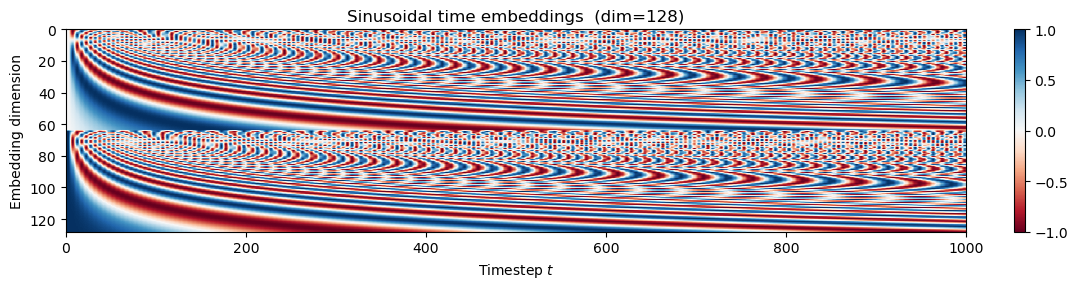

In [3]:
TIME_DIM = 128    # sinusoidal embedding dimension (must be even)


def sinusoidal_embedding(t_idx, dim=TIME_DIM):
    """
    Sinusoidal time embedding.

    emb(t)_{2i}   = sin(t / 10000^{2i/(dim-1)})
    emb(t)_{2i+1} = cos(t / 10000^{2i/(dim-1)})

    Parameters
    ----------
    t_idx : (B,)  integer timesteps in {0, ..., T-1}
    dim   : embedding dimension (even)

    Returns  emb : (B, dim)  float32
    """
    assert dim % 2 == 0, 'TIME_DIM must be even'
    half = dim // 2
    # Denominator: 10000^{2i/(dim-1)}  — guard against div-by-zero for dim=2
    denom = dim - 2 if dim > 2 else 1
    freqs = np.exp(-math.log(10000.0) * np.arange(half, dtype=np.float64) / denom)
    t_f   = np.asarray(t_idx, dtype=np.float64).reshape(-1, 1)  # (B, 1)
    args  = t_f * freqs[None, :]                                  # (B, half)
    return np.concatenate([np.sin(args), np.cos(args)],
                           axis=1).astype(np.float32)              # (B, dim)


# Visualise: embedding heatmap over all timesteps
t_test = np.array([0, 1, 250, 500, 750, 999])
emb    = sinusoidal_embedding(t_test)
print(f'Embedding shape: {emb.shape}   range: [{emb.min():.3f}, {emb.max():.3f}]')

fig, ax = plt.subplots(figsize=(11, 3))
ax.imshow(sinusoidal_embedding(np.arange(0, T, 5)).T,
          aspect='auto', cmap='RdBu', vmin=-1, vmax=1,
          extent=[0, T, TIME_DIM, 0])
ax.set(xlabel='Timestep $t$', ylabel='Embedding dimension',
       title=f'Sinusoidal time embeddings  (dim={TIME_DIM})')
plt.colorbar(ax.images[0], ax=ax, fraction=0.015)
plt.tight_layout()
plt.show()

## 5. Noise-Prediction Network and Backpropagation

### Architecture: time-conditioned residual MLP

Each **residual block** with input $h$ and time embedding $t$:

$$h_1 = \mathrm{ReLU}(W_1 h + b_1)$$
$$h_1 \leftarrow h_1 + W_t\,t_{\rm emb}$$
$$h_2 = \mathrm{ReLU}(W_2 h_1 + b_2)$$
$$\text{out} = h_2 + \text{skip}(h)$$

The **skip connection** is the identity when dimensions match, or a
learned projection $W_s h + b_s$ when they differ (block 0: $784\to 512$).

### Gradient derivation

The loss is $\mathcal{L} = \frac{1}{BD}\sum_{b,i}(\hat\varepsilon_{bi} - \varepsilon_{bi})^2$,
so the output gradient is:

$$\frac{\partial\mathcal{L}}{\partial\hat\varepsilon} = \frac{2}{BD}(\hat\varepsilon - \varepsilon)$$

Propagating back through the output layer and then through each residual
block in reverse order, using:

- ReLU: $\delta_{\rm pre} = \delta_{\rm post} \odot \mathbf{1}[\text{pre}>0]$
- Dense: $\nabla W = h^T \delta$, $\nabla b = \sum_b \delta$,
  $\delta_{\rm in} = \delta W^T$
- Residual: gradient splits and recombines across main and skip paths
- Time projection $W_t$: $\nabla W_t = t_{\rm emb}^T\,\delta_{h_1}$
  (time embedding itself has no learned parameters)

In [4]:
class DiffusionMLP:
    """
    Time-conditioned noise-prediction MLP  ε_θ(x_t, t).

    Three residual blocks with sinusoidal time injection at each block.
    All parameters in self.params; intermediate values in self.cache.

    Block k layout
    --------------
    h1       = ReLU(W1_k · h_in + b1_k)         main, first dense
    h1_cond  = h1 + Wt_k · t_emb                 add time
    h2       = ReLU(W2_k · h1_cond + b2_k)       main, second dense
    skip     = Ws_k · h_in + bs_k   (block 0 only, dim 784→512)
             = h_in                  (blocks 1,2   dim 512→512)
    out      = h2 + skip
    """

    def __init__(self, in_dim=784, width=512, time_dim=TIME_DIM,
                 n_blocks=3, rng_=None):
        if rng_ is None:
            rng_ = np.random.default_rng(42)
        self.in_dim   = in_dim
        self.width    = width
        self.time_dim = time_dim
        self.n_blocks = n_blocks
        self.cache    = {}
        p = {}

        for k in range(n_blocks):
            fan_in = in_dim if k == 0 else width
            p[f'W1_{k}'] = he_init(fan_in, width, rng_)
            p[f'b1_{k}'] = np.zeros(width, dtype=np.float32)
            p[f'W2_{k}'] = he_init(width,  width, rng_)
            p[f'b2_{k}'] = np.zeros(width, dtype=np.float32)
            # Time projection: time_dim → width  (no bias — standard practice)
            p[f'Wt_{k}'] = rng_.normal(0, 0.02,
                                        (time_dim, width)).astype(np.float32)
            # Skip projection only for block 0 (784→512 dim change)
            if fan_in != width:
                p[f'Ws_{k}'] = rng_.normal(0, 0.02,
                                            (fan_in, width)).astype(np.float32)
                p[f'bs_{k}'] = np.zeros(width, dtype=np.float32)

        # Output layer: no activation — predict raw noise values
        p['W_out'] = rng_.normal(0, 0.02, (width, in_dim)).astype(np.float32)
        p['b_out'] = np.zeros(in_dim, dtype=np.float32)

        self.params = p
        n_p = sum(v.size for v in p.values())
        print(f'DiffusionMLP: {in_dim}→{n_blocks}×[{width}]→{in_dim}')
        print(f'Parameters  : {n_p:,}')

    # ── Forward pass ──────────────────────────────────────────────────

    def forward(self, x_t, t_emb):
        """
        x_t   : (B, 784)      noisy image in [-1, 1]
        t_emb : (B, TIME_DIM) sinusoidal time embedding
        Returns eps_hat : (B, 784)  predicted noise
        """
        p, c = self.params, self.cache
        c['x_t']   = x_t
        c['t_emb'] = t_emb
        h = x_t

        for k in range(self.n_blocks):
            fan_in = self.in_dim if k == 0 else self.width

            # Main branch — first dense + ReLU
            pre1     = h @ p[f'W1_{k}'] + p[f'b1_{k}']     # (B, width)
            h1       = relu(pre1)

            # Time injection
            t_proj   = t_emb @ p[f'Wt_{k}']                 # (B, width)
            h1_cond  = h1 + t_proj                           # (B, width)

            # Main branch — second dense + ReLU
            pre2     = h1_cond @ p[f'W2_{k}'] + p[f'b2_{k}']  # (B, width)
            h2       = relu(pre2)

            # Skip connection
            if fan_in != self.width:
                skip = h @ p[f'Ws_{k}'] + p[f'bs_{k}']     # (B, width)
            else:
                skip = h                                      # identity
            out = h2 + skip

            # Cache all intermediates for backprop
            c[f'h_in_{k}']   = h
            c[f'pre1_{k}']   = pre1
            c[f'h1_cond_{k}'] = h1_cond
            c[f'pre2_{k}']   = pre2
            h = out

        c['h_final']  = h
        eps_hat       = h @ p['W_out'] + p['b_out']         # (B, 784)
        c['eps_hat']  = eps_hat
        return eps_hat

    # ── Loss ──────────────────────────────────────────────────────────

    def loss(self, eps_hat, eps_true):
        """MSE noise-prediction loss  L = mean ||ε - ε̂||²."""
        return float(np.mean((eps_hat - eps_true) ** 2))

    # ── Backward pass ─────────────────────────────────────────────────

    def backward(self, eps_true, x_t, t_emb):
        """
        Gradients of L = (1/BD) Σ (ε̂ - ε)² w.r.t. all parameters.
        Call after forward(x_t, t_emb).

        ∂L/∂ε̂     = 2(ε̂ - ε) / (B·D)          output gradient
        ∂L/∂W_out = h_final^T · d_out
        ∂L/∂b_out = Σ_B d_out

        Then for each block k in reverse:
          Split d_h → d_h2 (main) + d_skip (skip)
          d_h2       = d_h · ReLU'(pre2)
          ∂W2, ∂b2   from d_h2
          d_h1_cond  = d_h2 @ W2^T
          ∂Wt        = t_emb^T · d_h1_cond
          d_h1       = d_h1_cond · ReLU'(pre1)
          ∂W1, ∂b1   from d_h1
          d_h_in     = d_h1 @ W1^T  +  d_skip @ Ws^T (or d_h for identity skip)
        """
        p, c  = self.params, self.cache
        B, D  = x_t.shape
        grads = {}

        # ── Output layer ───────────────────────────────────────────────
        d_out          = 2.0 * (c['eps_hat'] - eps_true) / (B * D)  # (B, 784)
        grads['W_out'] = c['h_final'].T @ d_out                      # (width, 784)
        grads['b_out'] = d_out.sum(axis=0)                           # (784,)
        d_h            = d_out @ p['W_out'].T                        # (B, width)

        # ── Residual blocks in reverse ─────────────────────────────────
        for k in reversed(range(self.n_blocks)):
            fan_in = self.in_dim if k == 0 else self.width

            # --- Second dense + ReLU ---
            d_h2            = d_h * relu_grad(c[f'pre2_{k}'])        # (B, width)
            grads[f'W2_{k}']= c[f'h1_cond_{k}'].T @ d_h2            # (width, width)
            grads[f'b2_{k}']= d_h2.sum(axis=0)                       # (width,)
            d_h1_cond       = d_h2 @ p[f'W2_{k}'].T                  # (B, width)

            # --- Time projection (Wt has no bias) ---
            grads[f'Wt_{k}']= t_emb.T @ d_h1_cond                   # (time_dim, width)
            # d_h1_cond passes straight through the addition h1+t_proj

            # --- First dense + ReLU ---
            d_h1            = d_h1_cond * relu_grad(c[f'pre1_{k}'])  # (B, width)
            grads[f'W1_{k}']= c[f'h_in_{k}'].T @ d_h1               # (fan_in, width)
            grads[f'b1_{k}']= d_h1.sum(axis=0)                       # (width,)
            d_main          = d_h1 @ p[f'W1_{k}'].T                  # (B, fan_in)

            # --- Skip connection ---
            if fan_in != self.width:
                # Learned skip — gradient flows through Ws
                grads[f'Ws_{k}'] = c[f'h_in_{k}'].T @ d_h           # (fan_in, width)
                grads[f'bs_{k}'] = d_h.sum(axis=0)                   # (width,)
                d_skip           = d_h @ p[f'Ws_{k}'].T              # (B, fan_in)
            else:
                # Identity skip — gradient passes straight through
                d_skip = d_h                                           # (B, width)

            # Input gradient = main path + skip path
            d_h = d_main + d_skip                                      # (B, fan_in)

        return grads


# ── Sanity checks ─────────────────────────────────────────────────────
model = DiffusionMLP(in_dim=784, width=512, time_dim=TIME_DIM,
                     n_blocks=3, rng_=rng)

_x  = rng.standard_normal((6, 784)).astype(np.float32)
_te = sinusoidal_embedding(np.array([0, 100, 300, 600, 800, 999]))
_eh = model.forward(_x, _te)
assert _eh.shape == (6, 784), f'Bad output shape: {_eh.shape}'

_et  = rng.standard_normal((6, 784)).astype(np.float32)
_g   = model.backward(_et, _x, _te)
bad  = [k for k in model.params if _g[k].shape != model.params[k].shape]
assert not bad, f'Shape mismatches: {bad}'
print(f'Forward output shape : {_eh.shape}  ✓')
print(f'Gradient shapes OK   : {len(_g)} parameter tensors  ✓')
print(f'Loss on random data  : {model.loss(_eh, _et):.4f}')

DiffusionMLP: 784→3×[512]→784
Parameters  : 2,715,920
Forward output shape : (6, 784)  ✓
Gradient shapes OK   : 19 parameter tensors  ✓
Loss on random data  : 3.0049


## 7. MNIST Loading

Downloads raw MNIST binary files with `urllib`, parses them with `gzip`
and `struct`, then rescales pixels from $[0,1]$ to $[-1,1]$.

**Why $[-1,1]$?**  Diffusion models add zero-mean Gaussian noise.  Centring
the data around zero makes the noise model symmetric and numerically stable;
the network predicts noise $\varepsilon\sim\mathcal{N}(0,\mathbf{I})$
which has the same scale as the centred data.

A `torchvision` fallback is included if direct download fails.

donewnloading train-labels-idx1-ubyte.gz... 
donewnloading t10k-images-idx3-ubyte.gz... 
donewnloading t10k-labels-idx1-ubyte.gz... 
Train : (60000, 784)   pixel range [-1.0, 1.0]
Test  : (10000, 784)


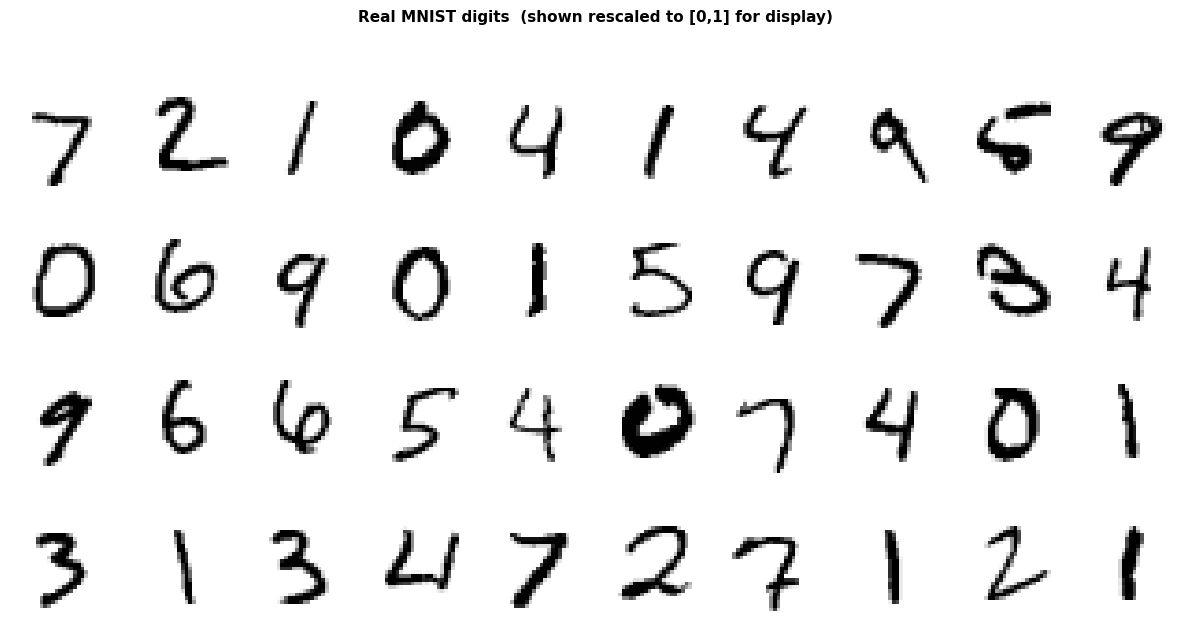

In [5]:
MNIST_URL   = 'https://ossci-datasets.s3.amazonaws.com/mnist/'
MNIST_FILES = {
    'train_images': 'train-images-idx3-ubyte.gz',
    'train_labels': 'train-labels-idx1-ubyte.gz',
    'test_images':  't10k-images-idx3-ubyte.gz',
    'test_labels':  't10k-labels-idx1-ubyte.gz',
}

def _download(d='./data/mnist'):
    d = Path(d); d.mkdir(parents=True, exist_ok=True)
    for name, fname in MNIST_FILES.items():
        fp = d / fname
        if not fp.exists():
            print(f'  Downloading {fname}...', end=' ', flush=True)
            try:
                urllib.request.urlretrieve(MNIST_URL + fname, fp)
                print('done')
            except Exception as e:
                print(f'FAILED ({e})')

def _parse_images(path):
    with gzip.open(path, 'rb') as f:
        _, n, rows, cols = struct.unpack('>IIII', f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows * cols).astype(np.float32) / 255.0

def _parse_labels(path):
    with gzip.open(path, 'rb') as f:
        f.read(8)   # skip magic + count
        return np.frombuffer(f.read(), dtype=np.uint8)

def load_mnist(d='./data/mnist'):
    """
    Load MNIST, rescale pixels to [-1, 1].
    Returns (X_train, y_train, X_test, y_test).
    X arrays: (N, 784) float32 in [-1, 1].
    """
    _download(d); d = Path(d)
    try:
        Xtr = _parse_images(d / MNIST_FILES['train_images'])
        ytr = _parse_labels(d / MNIST_FILES['train_labels'])
        Xte = _parse_images(d / MNIST_FILES['test_images'])
        yte = _parse_labels(d / MNIST_FILES['test_labels'])
    except Exception as e:
        print(f'Direct load failed ({e}) — using torchvision fallback')
        from torchvision import datasets, transforms
        tf = transforms.ToTensor()
        def _tv(split):
            ds = datasets.MNIST('./data', train=split, download=True, transform=tf)
            X  = np.stack([im.numpy().flatten() for im, _ in ds]).astype(np.float32)
            y  = np.array([lb for _, lb in ds], dtype=np.uint8)
            return X, y
        Xtr, ytr = _tv(True)
        Xte, yte = _tv(False)
    # Rescale [0,1] → [-1,1]
    return 2*Xtr - 1, ytr, 2*Xte - 1, yte


X_train, y_train, X_test, y_test = load_mnist()
print(f'Train : {X_train.shape}   pixel range [{X_train.min():.1f}, {X_train.max():.1f}]')
print(f'Test  : {X_test.shape}')

show_grid((X_test[:40] + 1) / 2, nrow=10,
          title='Real MNIST digits  (shown rescaled to [0,1] for display)')

## 8. Forward Diffusion — Visualising Noise Addition

The closed-form marginal $q(x_t|x_0)$ lets us jump directly to any
noise level without iterating through all intermediate steps.

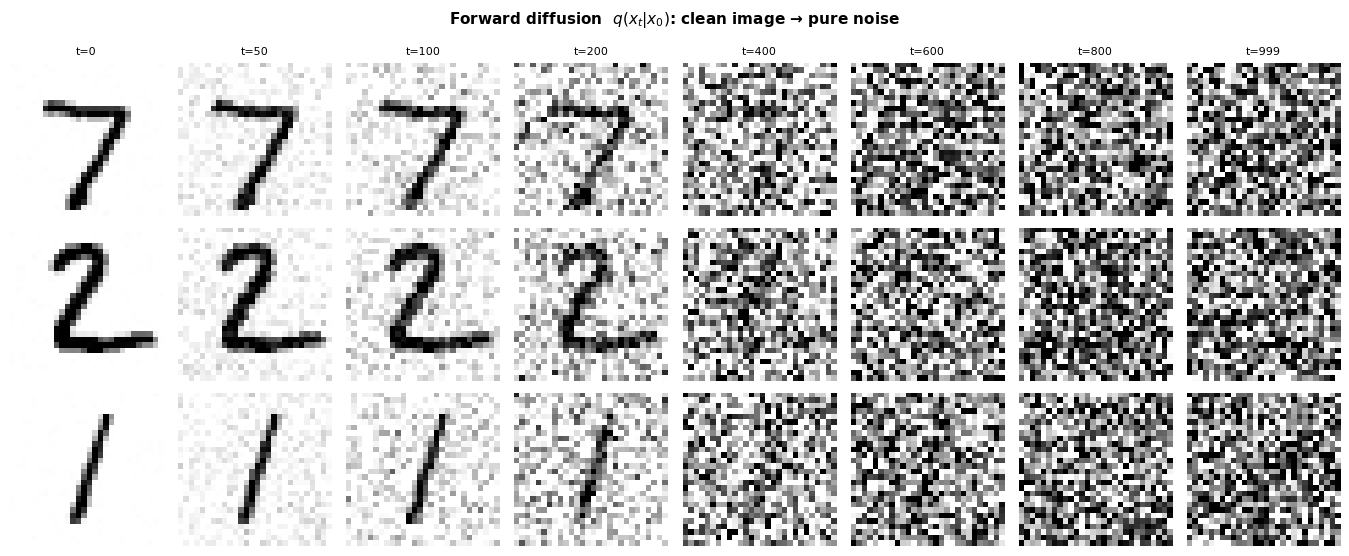

In [6]:
# Show how three test digits are progressively noised
steps_shown = [0, 50, 100, 200, 400, 600, 800, 999]
n_demo      = 3

fig, axes = plt.subplots(n_demo, len(steps_shown),
                          figsize=(len(steps_shown) * 1.7, n_demo * 1.9),
                          squeeze=False)
for row in range(n_demo):
    x0 = X_test[row : row + 1]
    for col, t in enumerate(steps_shown):
        x_noisy, _ = q_sample(x0, np.array([t]))
        img = ((x_noisy[0] + 1) / 2).clip(0, 1).reshape(28, 28)
        axes[row, col].imshow(img, cmap='gray_r', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f't={t}', fontsize=8)

fig.suptitle('Forward diffusion  $q(x_t|x_0)$: clean image → pure noise',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Training

Each mini-batch step:
1. Draw a batch of clean images $x_0$
2. Sample random timesteps $t\sim\mathrm{Uniform}\{0,\ldots,T-1\}$
3. Sample noise $\varepsilon\sim\mathcal{N}(0,\mathbf{I})$
4. Compute noisy images $x_t$ using the closed-form marginal
5. Predict noise $\hat\varepsilon = \varepsilon_\theta(x_t,t)$
6. Compute MSE loss $\|\varepsilon - \hat\varepsilon\|^2$
7. Backprop and Adam step

**Note on speed:** pure NumPy matrix multiplies over 60k samples × 512
width × 784 dims are slower than PyTorch (no GPU, no fused ops).  15
epochs is a good starting point; more epochs improve generation quality.

In [7]:
EPOCHS     = 15
BATCH_SIZE = 256
LR         = 2e-4

opt       = Adam(lr=LR)
n_train   = len(X_train)
history   = {'loss': []}
t0_train  = time.time()

print(f'Training DDPM — noise-prediction MSE')
print(f'  T={T}, epochs={EPOCHS}, batch={BATCH_SIZE}, lr={LR}')
print(f'  Network: 784 → {model.n_blocks}×[{model.width}] → 784')
print()

for ep in range(1, EPOCHS + 1):
    t_ep    = time.time()
    perm    = rng.permutation(n_train)
    ep_loss = 0.0
    n_bat   = 0

    for s in range(0, n_train, BATCH_SIZE):
        xb    = X_train[perm[s : s + BATCH_SIZE]]          # (B, 784)
        B     = len(xb)

        # Randomly sample one timestep per image
        t_idx = rng.integers(0, T, size=B)                  # (B,)
        t_emb = sinusoidal_embedding(t_idx)                  # (B, TIME_DIM)

        # One-shot forward diffusion
        eps        = rng.standard_normal(xb.shape).astype(np.float32)
        x_t, eps   = q_sample(xb, t_idx, eps)               # (B, 784)

        # Forward pass: predict the noise
        eps_hat    = model.forward(x_t, t_emb)               # (B, 784)

        # Loss and backward
        batch_loss = model.loss(eps_hat, eps)
        grads      = model.backward(eps, x_t, t_emb)
        opt.update(model.params, grads)

        ep_loss += batch_loss
        n_bat   += 1

    ep_loss /= n_bat
    history['loss'].append(ep_loss)
    print(f'  Epoch {ep:3d}/{EPOCHS}  '
          f'loss = {ep_loss:.6f}  '
          f'({time.time() - t_ep:.1f}s)')

print(f'\nTotal training time: {time.time() - t0_train:.1f}s')

Training DDPM — noise-prediction MSE
  T=1000, epochs=15, batch=256, lr=0.0002
  Network: 784 → 3×[512] → 784

  Epoch   1/15  loss = 1.013482  (34.8s)
  Epoch   2/15  loss = 0.797414  (45.0s)
  Epoch   3/15  loss = 0.655743  (34.1s)
  Epoch   4/15  loss = 0.557507  (41.1s)
  Epoch   5/15  loss = 0.494702  (43.9s)
  Epoch   6/15  loss = 0.462389  (34.4s)
  Epoch   7/15  loss = 0.445530  (34.8s)
  Epoch   8/15  loss = 0.439963  (36.8s)
  Epoch   9/15  loss = 0.435521  (31.6s)
  Epoch  10/15  loss = 0.434123  (33.9s)
  Epoch  11/15  loss = 0.431709  (31.6s)
  Epoch  12/15  loss = 0.431251  (33.0s)
  Epoch  13/15  loss = 0.429404  (33.5s)
  Epoch  14/15  loss = 0.429893  (31.7s)
  Epoch  15/15  loss = 0.427545  (40.3s)

Total training time: 540.5s


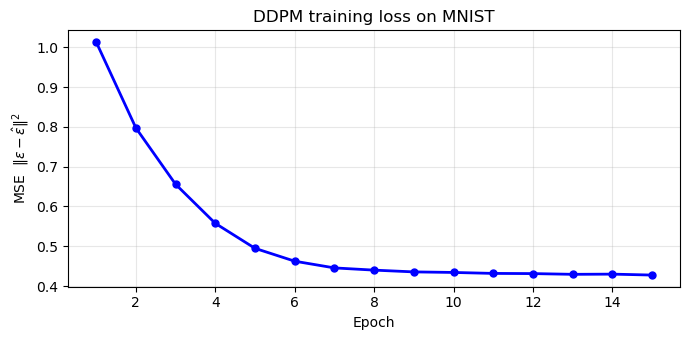

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(range(1, EPOCHS + 1), history['loss'], 'b-o', ms=5, lw=2)
ax.set(xlabel='Epoch',
       ylabel=r'MSE  $\|\varepsilon - \hat{\varepsilon}\|^2$',
       title='DDPM training loss on MNIST')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. DDPM Sampling — Full 1000-Step Reverse Chain

Start from $x_T\sim\mathcal{N}(0,\mathbf{I})$ and apply the learned
reverse step 1000 times:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\!
\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\hat\varepsilon_t\right)
+\sqrt{\tilde\beta_t}\,z,\qquad z\sim\mathcal{N}(0,\mathbf{I})$$

At $t=0$ we set $z=0$ (no noise at the final step).

> **Pure NumPy speed note:** 1000 forward passes over a width-512 MLP
> takes several minutes on CPU.  Section 11 shows DDIM at 50 steps.

DDPM sampling (1000 steps) — this may take a few minutes...
  t= 800   range [-19.78, 20.48]
  t= 600   range [-83.69, 83.60]
  t= 400   range [-237.48, 229.14]
  t= 200   range [-442.56, 425.34]
  t=   0   range [-550.84, 526.07]
Done in 2.9s


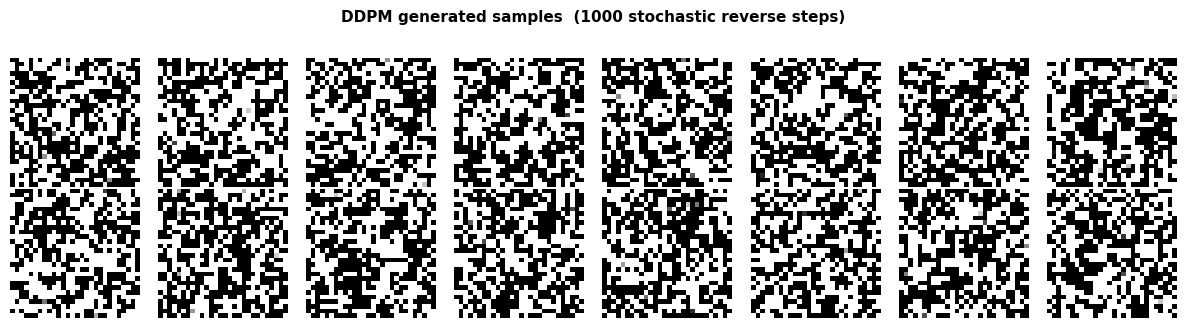

In [9]:
def ddpm_sample(mdl, n_samples=16, verbose=True):
    """
    DDPM stochastic reverse chain  x_T → x_0.

    x_{t-1} = (1/√α_t)(x_t - β_t/√(1-ᾱ_t) ε̂_t) + √β̃_t z
    """
    x = rng.standard_normal((n_samples, 784)).astype(np.float32)

    for t in reversed(range(T)):
        t_arr   = np.full(n_samples, t, dtype=np.int64)
        t_emb   = sinusoidal_embedding(t_arr)
        eps_hat = mdl.forward(x, t_emb)

        # Reverse mean
        coef = betas_f32[t] / sqrt_1m_ab[t]
        mean = (x - coef * eps_hat) / np.sqrt(alphas[t])

        # Add posterior noise (skip at t=0)
        if t > 0:
            z = rng.standard_normal(x.shape).astype(np.float32)
            x = mean + np.sqrt(posterior_var[t]) * z
        else:
            x = mean

        if verbose and t % 200 == 0:
            print(f'  t={t:4d}   range [{x.min():.2f}, {x.max():.2f}]')

    return x


print('DDPM sampling (1000 steps) — this may take a few minutes...')
t0 = time.time()
x_ddpm = ddpm_sample(model, n_samples=16, verbose=True)
print(f'Done in {time.time()-t0:.1f}s')

show_grid((x_ddpm + 1) / 2, nrow=8,
          title='DDPM generated samples  (1000 stochastic reverse steps)')

## 11. DDIM Accelerated Sampling — 50 Deterministic Steps

DDIM (Song et al., 2020) rewrites the reverse process as a
non-Markovian chain that can skip timesteps.  With $\eta=0$ it is
fully **deterministic** — the same noise seed always produces the same image.

At each of the $S=50$ selected steps:

1. Predict clean image from current $x_t$:
   $\hat{x}_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\,\hat\varepsilon_t}
   {\sqrt{\bar\alpha_t}}$
2. Re-noise to previous timestep level:
   $x_{t-1} = \sqrt{\bar\alpha_{t-1}}\,\hat{x}_0
   + \sqrt{1-\bar\alpha_{t-1}}\,\hat\varepsilon_t$

This is $\approx 20\times$ faster than DDPM with similar quality.

DDIM sampling (50 steps)...
  step   0/50  t= 999  range [-4.95, 4.30]
  step  10/50  t= 795  range [-13.27, 14.52]
  step  20/50  t= 591  range [-1312.15, 1293.20]
  step  30/50  t= 387  range [-80643.94, 79777.20]
  step  40/50  t= 183  range [-206685.52, 204457.73]
Done in 0.7s


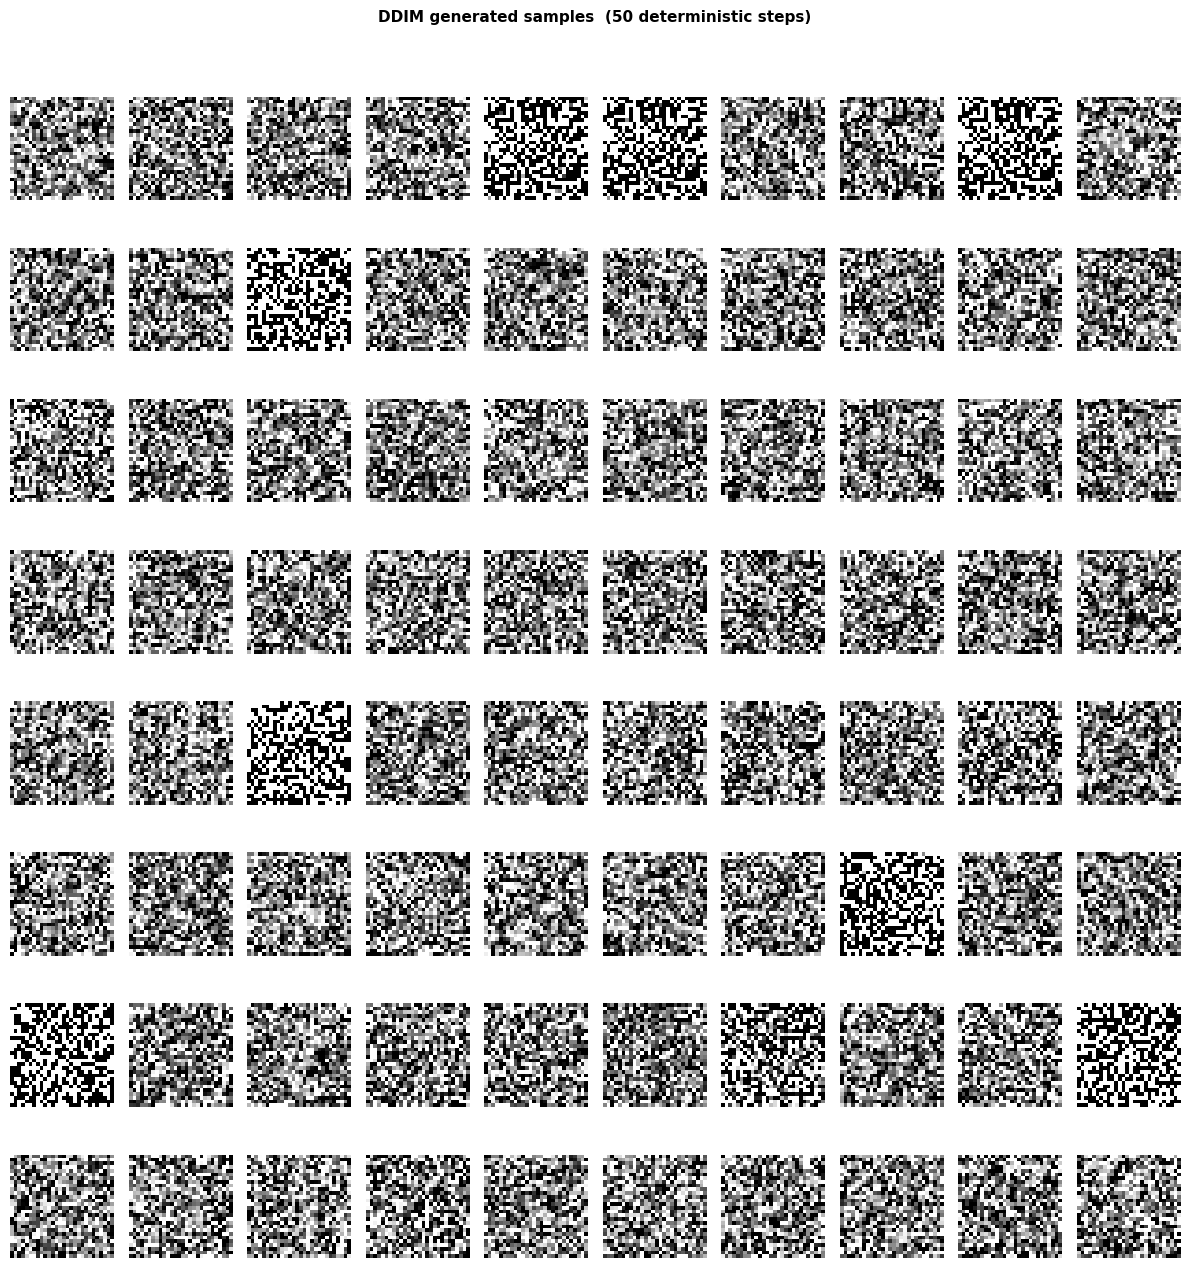

In [10]:
def ddim_sample(mdl, n_samples=16, n_steps=50, verbose=True):
    """
    Deterministic DDIM reverse chain  (η=0).

    Selects n_steps evenly-spaced timesteps from {0,...,T-1},
    runs them in decreasing order.
    """
    # Choose timesteps: evenly spaced, descending
    tau = np.linspace(0, T - 1, n_steps, dtype=int)  # ascending
    tau = tau[::-1]                                    # descending: T-1 → 0

    x = rng.standard_normal((n_samples, 784)).astype(np.float32)

    for i, t in enumerate(tau):
        t_arr   = np.full(n_samples, t, dtype=np.int64)
        t_emb   = sinusoidal_embedding(t_arr)
        eps_hat = mdl.forward(x, t_emb)

        ab_t    = alpha_bar[t]
        # Previous ᾱ: next element in tau (smaller t), or 1.0 at the end
        ab_prev = alpha_bar[tau[i + 1]] if i + 1 < n_steps else 1.0

        # Predict x0, apply mild clamp for stability
        x0_pred = (x - np.sqrt(1 - ab_t) * eps_hat) / np.sqrt(ab_t)
        x0_pred = x0_pred.clip(-2.0, 2.0)

        # DDIM deterministic step
        x = np.sqrt(ab_prev) * x0_pred + np.sqrt(1 - ab_prev) * eps_hat

        if verbose and i % 10 == 0:
            print(f'  step {i:3d}/{n_steps}  t={t:4d}'
                  f'  range [{x.min():.2f}, {x.max():.2f}]')

    return x


print('DDIM sampling (50 steps)...')
t0 = time.time()
x_ddim = ddim_sample(model, n_samples=80, n_steps=50, verbose=True)
print(f'Done in {time.time()-t0:.1f}s')

show_grid((x_ddim + 1) / 2, nrow=10,
          title='DDIM generated samples  (50 deterministic steps)')

## 12. Analysis

Three diagnostics that reveal whether and how well the model has learned:

1. **Single-step $x_0$ reconstruction** — how faithfully $\varepsilon_\theta$
   can invert the noise at different levels
2. **DDIM chain evolution** — watching noise condense into a digit over 50 steps
3. **Noise prediction scatter** — $\varepsilon$ vs $\hat\varepsilon$ at three
   timesteps; points on the diagonal indicate perfect prediction

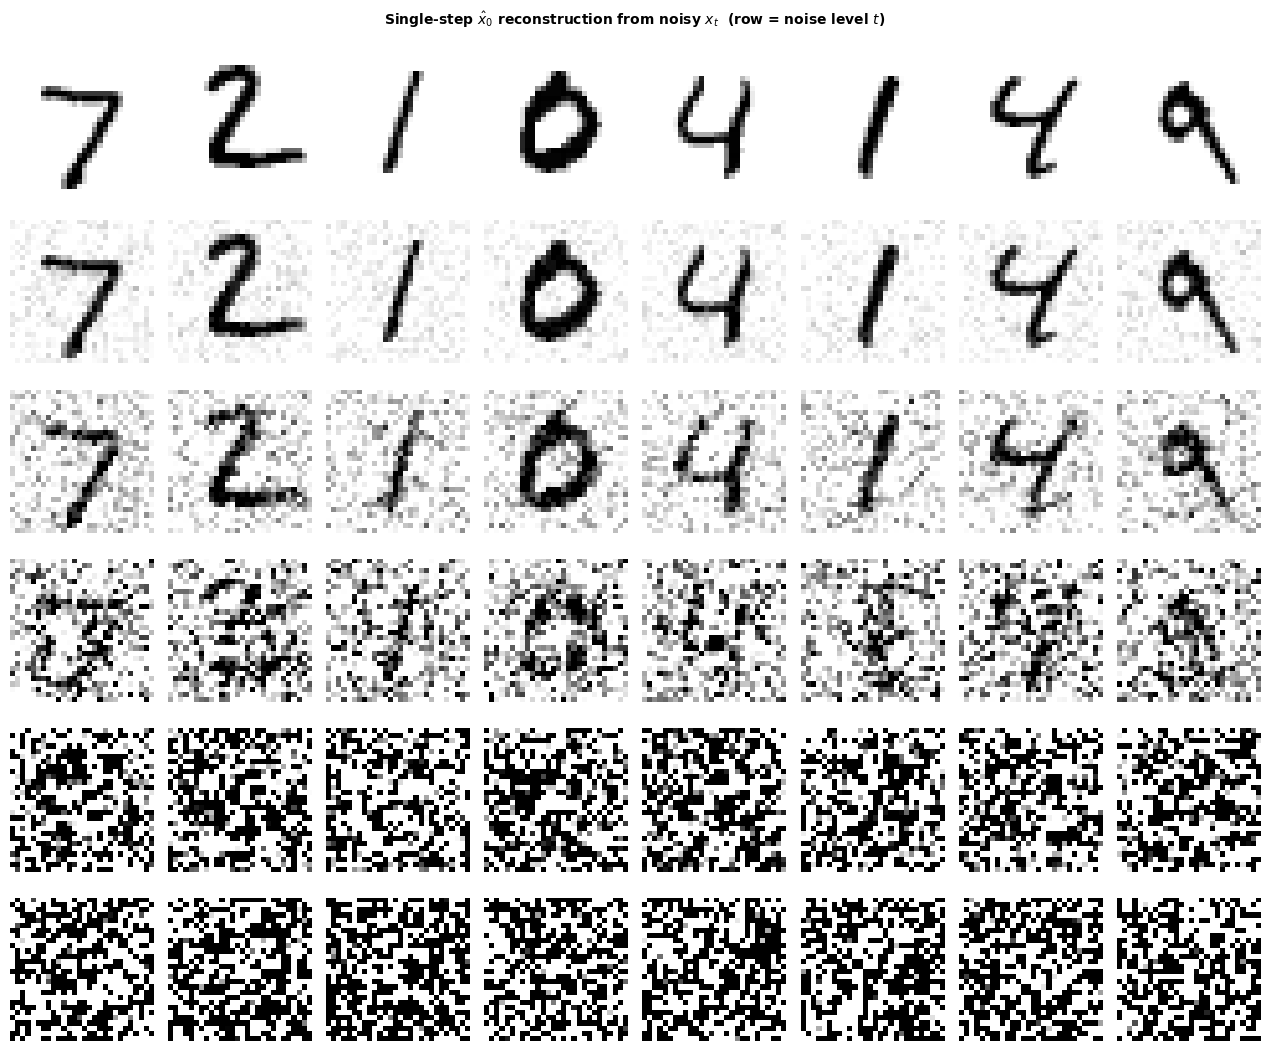

In [11]:
# ── Single-step x0 reconstruction at different noise levels ──────────
t_vals  = [50, 200, 400, 700, 900]
n_eval  = 8
x0_eval = X_test[:n_eval]

fig, axes = plt.subplots(len(t_vals) + 1, n_eval,
                          figsize=(n_eval * 1.6, (len(t_vals) + 1) * 1.8),
                          squeeze=False)
# Row 0: original clean images
for j in range(n_eval):
    axes[0, j].imshow(((x0_eval[j] + 1) / 2).reshape(28, 28),
                      cmap='gray_r', vmin=0, vmax=1)
    axes[0, j].axis('off')
axes[0, 0].set_ylabel('Clean', fontsize=8, rotation=0,
                       labelpad=30, va='center')

for row, t in enumerate(t_vals, 1):
    t_arr        = np.full(n_eval, t)
    x_noisy, _   = q_sample(x0_eval, t_arr)
    t_emb        = sinusoidal_embedding(t_arr)
    eps_hat      = model.forward(x_noisy, t_emb)
    # x0_hat = (x_t - √(1-ᾱ_t) ε̂) / √ᾱ_t
    x0_hat       = (x_noisy - sqrt_1m_ab[t] * eps_hat) / sqrt_ab[t]
    for j in range(n_eval):
        axes[row, j].imshow(((x0_hat[j] + 1) / 2).clip(0, 1).reshape(28, 28),
                            cmap='gray_r', vmin=0, vmax=1)
        axes[row, j].axis('off')
    axes[row, 0].set_ylabel(f't={t}', fontsize=8, rotation=0,
                            labelpad=30, va='center')

fig.suptitle(r'Single-step $\hat{x}_0$ reconstruction from noisy $x_t$'
             r'  (row = noise level $t$)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

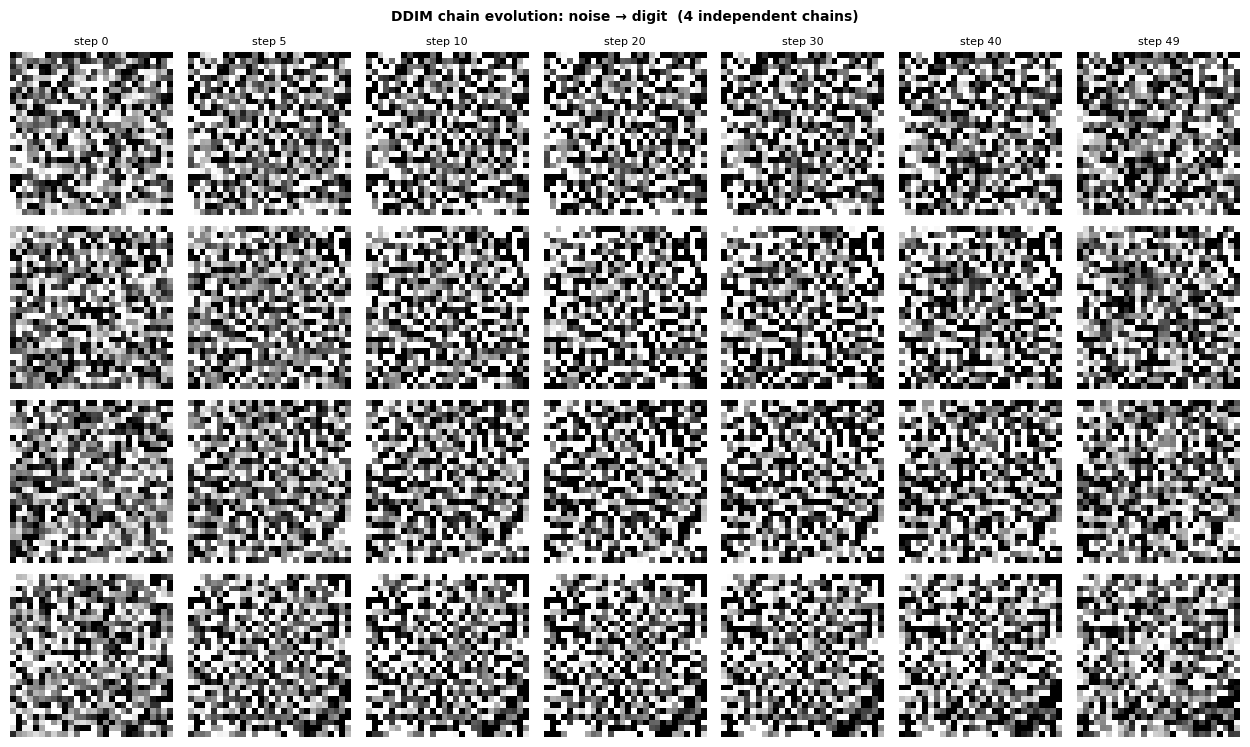

In [12]:
# ── DDIM chain evolution snapshots ────────────────────────────────────
n_steps    = 50
tau        = np.linspace(0, T - 1, n_steps, dtype=int)[::-1]
snap_at    = {0, 5, 10, 20, 30, 40, 49}   # which DDIM steps to record
n_chains   = 4                              # parallel chains to visualise

x_ev = rng.standard_normal((n_chains, 784)).astype(np.float32)
snaps = {}     # step_i → (n_chains, 28, 28)

for i, t in enumerate(tau):
    if i in snap_at:
        snaps[i] = ((x_ev + 1) / 2).clip(0, 1).reshape(n_chains, 28, 28).copy()

    t_arr   = np.full(n_chains, t, dtype=np.int64)
    t_emb   = sinusoidal_embedding(t_arr)
    eps_hat = model.forward(x_ev, t_emb)
    ab_t    = alpha_bar[t]
    ab_prev = alpha_bar[tau[i + 1]] if i + 1 < n_steps else 1.0
    x0_pred = (x_ev - np.sqrt(1 - ab_t) * eps_hat) / np.sqrt(ab_t)
    x0_pred = x0_pred.clip(-2.0, 2.0)
    x_ev    = np.sqrt(ab_prev) * x0_pred + np.sqrt(1 - ab_prev) * eps_hat

# Final state
snaps[n_steps - 1] = ((x_ev + 1) / 2).clip(0, 1).reshape(n_chains, 28, 28)

ordered = sorted(snaps.items())   # ascending step order
n_cols  = len(ordered)
fig, axes = plt.subplots(n_chains, n_cols,
                          figsize=(n_cols * 1.8, n_chains * 1.9),
                          squeeze=False)
for row in range(n_chains):
    for col, (step_i, imgs) in enumerate(ordered):
        axes[row, col].imshow(imgs[row], cmap='gray_r', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'step {step_i}', fontsize=8)

fig.suptitle('DDIM chain evolution: noise → digit  (4 independent chains)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

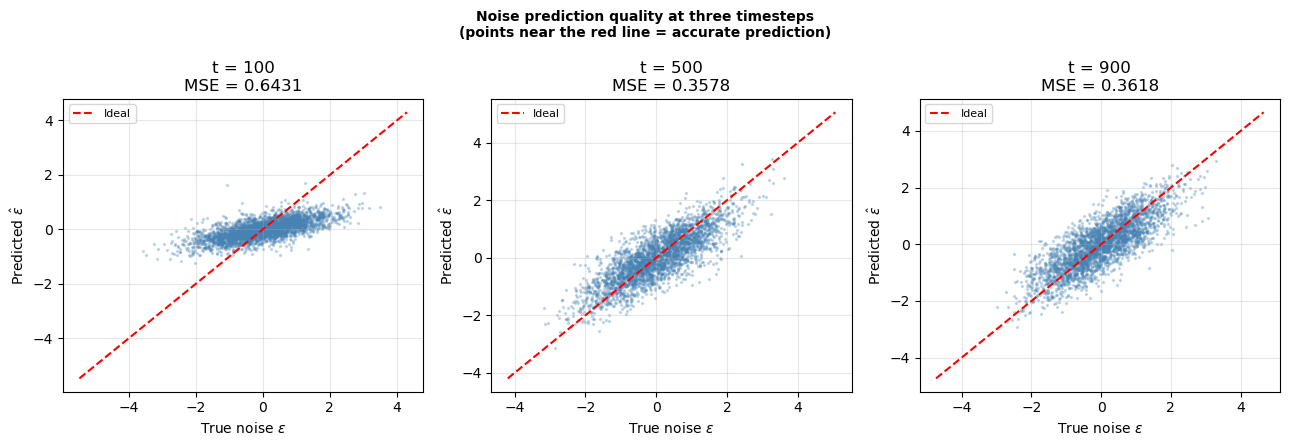

In [13]:
# ── Noise prediction quality: ε vs ε̂ scatter ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), squeeze=False)
t_scatter = [100, 500, 900]
n_sc      = 512   # images per panel
x0_sc     = X_test[:n_sc]

for ax, t in zip(axes[0], t_scatter):
    t_arr    = np.full(n_sc, t)
    x_t, eps = q_sample(x0_sc, t_arr)
    t_emb    = sinusoidal_embedding(t_arr)
    eps_hat  = model.forward(x_t, t_emb)
    mse      = float(np.mean((eps - eps_hat) ** 2))

    # Subsample pixel values for scatter
    idx_s = rng.integers(0, n_sc,  3000)
    idx_p = rng.integers(0, 784,   3000)
    ax.scatter(eps[idx_s, idx_p], eps_hat[idx_s, idx_p],
               s=2, alpha=0.25, color='steelblue')
    lo = min(eps.min(), eps_hat.min())
    hi = max(eps.max(), eps_hat.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Ideal')
    ax.set(xlabel=r'True noise $\varepsilon$',
           ylabel=r'Predicted $\hat{\varepsilon}$',
           title=f't = {t}\nMSE = {mse:.4f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Noise prediction quality at three timesteps\n'
             '(points near the red line = accurate prediction)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

| Component | Implementation |
|:----------|:--------------|
| **Forward process** | $\beta$ linear $10^{-4}\to 0.02$, $T=1000$; one-shot via $q(x_t|x_0)$ |
| **Network** | MLP: 3 residual blocks, width 512, sinusoidal $t$-emb (dim 128) |
| **Training** | Noise-prediction MSE, Adam, 15 epochs |
| **Backprop** | Full manual derivation through residual + time-projection blocks |
| **DDPM** | 1000 stochastic reverse steps |
| **DDIM** | 50 deterministic reverse steps, $\approx20\times$ faster |
| **Framework** | Pure NumPy — no PyTorch or TensorFlow |

### Comparison with VAE and RBM

| | RBM | VAE | DDPM |
|:-|:----|:----|:-----|
| Latent representation | Binary $h$ | Gaussian $z$ | None (implicit) |
| Training signal | Contrastive divergence | ELBO (BCE + KL) | Noise MSE |
| Sampling mechanism | Gibbs chain | Single decode | 1000-step reverse |
| Mode coverage | Moderate | Good | Excellent |
| Sample speed | Fast | Instant | Slow (pure NumPy) |
| Framework | NumPy | NumPy | NumPy |